In [1]:
import xarray as xr

detr_field = xr.open_dataarray("detr_field.nc")
detr_field

<xarray.DataArray (time: 276, lat: 36, lon: 61)> Size: 5MB
[606096 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2025-12-01
  * lat      (lat) float32 144B 14.5 15.5 16.5 17.5 18.5 ... 46.5 47.5 48.5 49.5
  * lon      (lon) float32 244B -126.5 -125.5 -124.5 ... -68.5 -67.5 -66.5

In [2]:
import numpy as np

print("Shape     :", detr_field.shape)
print("Dims      :", detr_field.dims)
print("Time      :", detr_field.time.values[0], "->", detr_field.time.values[-1], f"  ({len(detr_field.time)} months)")
print("Lat       :", float(detr_field.lat.min()), "->", float(detr_field.lat.max()), f"  ({len(detr_field.lat)} pts)")
print("Lon       :", float(detr_field.lon.min()), "->", float(detr_field.lon.max()), f"  ({len(detr_field.lon)} pts)")
print("Min / Max :", np.nanmin(detr_field.values), "/", np.nanmax(detr_field.values))
print("NaNs      :", int(np.isnan(detr_field.values).sum()))

Shape     : (276, 36, 61)
Dims      : ('time', 'lat', 'lon')
Time      : 2003-01-01T00:00:00.000000000 -> 2025-12-01T00:00:00.000000000   (276 months)
Lat       : 14.5 -> 49.5   (36 pts)
Lon       : -126.5 -> -66.5   (61 pts)
Min / Max : -2.968342862295363e-08 / 6.809900637206061e-08
NaNs      : 0


## Harmonic analysis : 12 months, 6 months and 4 months harmonics

At every spatial grid point, the time series of the data is mathematically modeled as a superposition of fundamental cyclical waves—specifically, annual, semi-annual, and terannual cycles. Each cycle is initially constructed from a pair of cosine and sine functions, $a\cos(\omega t) + b\sin(\omega t)$. A least-squares regression is applied at each individual grid point to calculate the specific coefficients ($a$ and $b$) that best fit the model to the observed data. Once these coefficients are determined, the components are rearranged into the cosine convention, $A\cos(\omega t - \phi)$. The amplitude ($A$), representing the maximum strength of the cycle, is derived using the Pythagorean theorem $\sqrt{a^2 + b^2}$, and the phase ($\phi$), representing the timing of the cycle's peak, is found via the inverse tangent $\arctan(b/a)$. A positive phase $\phi$ indicates that the peak of the cosine wave is shifted forward in time (i.e., the peak occurs later than $t=0$). Finally, to allow for direct temporal comparison across different wave frequencies, the resulting phase angles are proportionally scaled to a unified 12-month calendar, ensuring that a given angular shift universally corresponds to the exact same physical time step across all cycles.

In [3]:
import numpy as np
import pandas as pd

months = pd.date_range(detr_field.time.values[0], detr_field.time.values[-1], freq="MS")
n_lat  = len(detr_field.lat)
n_lon  = len(detr_field.lon)
lats   = detr_field.lat.values
lons   = detr_field.lon.values

# Setup and design matrix for harmonic regression
periods = [12, 6, 4]
t = np.arange(len(months))
print(f"Time vector t: {t} with shape {t.shape}  (0 to {len(months)-1})")

cols = []
for P in periods:
    w = 2 * np.pi / P
    cols += [np.cos(w * t), np.sin(w * t)]

# M: (n_months, 2*len(periods))
M = np.column_stack(cols)
print(f"Design matrix M: {M} with shape {M.shape}  (time x 2*len(periods))")

# Flatten spatial dims and solve least-squares at every pixel at once
Yd   = detr_field.values.reshape(len(months), -1)
coef, *_ = np.linalg.lstsq(M, Yd, rcond=None)

Time vector t: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242

In [16]:
# print first 10 coefficients
print(M[:10])

[[ 1.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00]
 [ 8.66025404e-01  5.00000000e-01  5.00000000e-01  8.66025404e-01
   6.12323400e-17  1.00000000e+00]
 [ 5.00000000e-01  8.66025404e-01 -5.00000000e-01  8.66025404e-01
  -1.00000000e+00  1.22464680e-16]
 [ 6.12323400e-17  1.00000000e+00 -1.00000000e+00  1.22464680e-16
  -1.83697020e-16 -1.00000000e+00]
 [-5.00000000e-01  8.66025404e-01 -5.00000000e-01 -8.66025404e-01
   1.00000000e+00 -2.44929360e-16]
 [-8.66025404e-01  5.00000000e-01  5.00000000e-01 -8.66025404e-01
   3.06161700e-16  1.00000000e+00]
 [-1.00000000e+00  1.22464680e-16  1.00000000e+00 -2.44929360e-16
  -1.00000000e+00  3.67394040e-16]
 [-8.66025404e-01 -5.00000000e-01  5.00000000e-01  8.66025404e-01
  -4.28626380e-16 -1.00000000e+00]
 [-5.00000000e-01 -8.66025404e-01 -5.00000000e-01  8.66025404e-01
   1.00000000e+00 -4.89858720e-16]
 [-1.83697020e-16 -1.00000000e+00 -1.00000000e+00  3.67394040e-16
   5.51091060e-16  1.0000

In [17]:
np.cos(90 * np.pi / 180)

np.float64(6.123233995736766e-17)

In [4]:
amp, pha = {}, {}

for k, P in enumerate(periods):
    # a -> cosine coefficient, b -> sine coefficient
    a_k = coef[2*k    ].reshape(n_lat, n_lon)
    b_k = coef[2*k + 1].reshape(n_lat, n_lon)

    # Amplitude: same as sine convention
    amp[P] = np.sqrt(a_k**2 + b_k**2)

    # Phase for A*cos(wt - phi):  phi = arctan2(b, a)
    # phi > 0 means the peak is delayed relative to t=0
    pha_rad = np.arctan2(b_k, a_k)

    # Map (-pi, pi) -> (0, 2*pi)
    pha_rad = np.where(pha_rad < 0, pha_rad + 2 * np.pi, pha_rad)

    pha_deg = pha_rad * (180 / np.pi)
    pha[P]  = pha_deg

    print(f"{P}: amp {np.nanmin(amp[P]):.2e} - {np.nanmax(amp[P]):.2e} kg/kg, "
          f"pha {np.nanmin(pha[P]):.2f} - {np.nanmax(pha[P]):.2f} degrees")

12: amp 3.52e-09 - 1.78e-08 kg/kg, pha 52.67 - 140.48 degrees
6: amp 1.06e-09 - 7.56e-09 kg/kg, pha 95.91 - 224.52 degrees
4: amp 9.36e-10 - 5.53e-09 kg/kg, pha 234.73 - 355.69 degrees


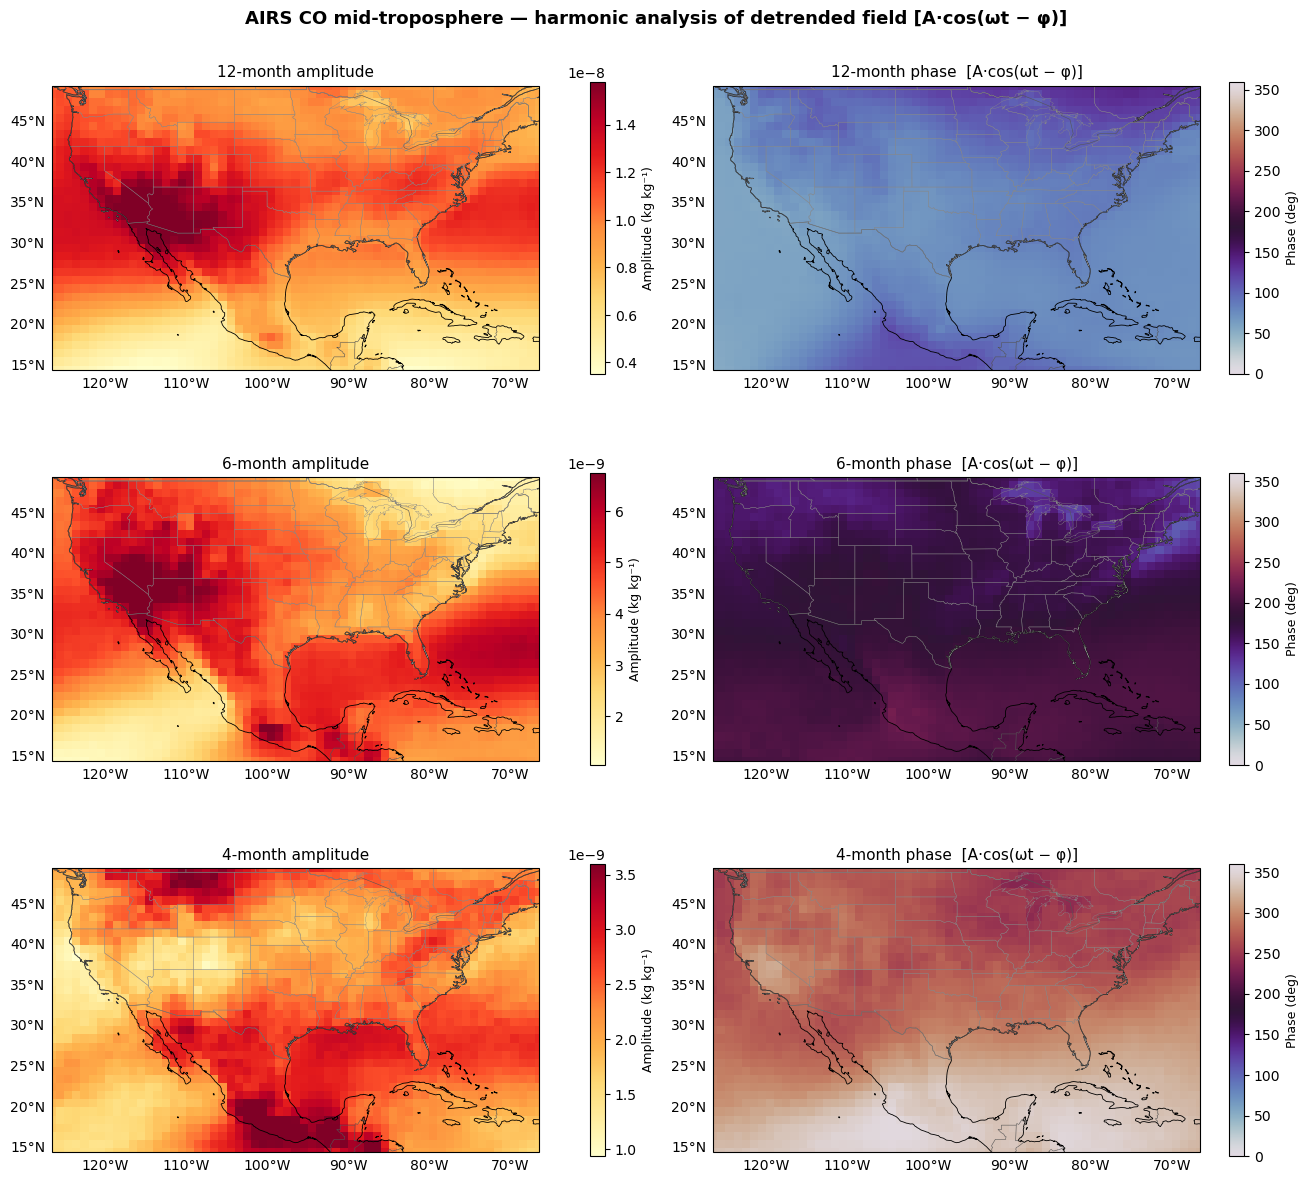

Saved -> ../Figures\harmonics_amp_phase_cos_2003_2025.png


In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import os

OUT_DIR = "../Figures"
os.makedirs(OUT_DIR, exist_ok=True)

ext = [float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())]

fig_h, axes_h = plt.subplots(
    len(periods), 2, figsize=(13, 4 * len(periods)),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True,
)

def harm_map(ax, data, cmap, label, title, vmin=None, vmax=None):
    ax.set_extent(ext, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
    ax.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")
    pcm = ax.pcolormesh(lons, lats, data, transform=ccrs.PlateCarree(),
                        cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest")
    gl = ax.gridlines(draw_labels=True, linewidth=0, color="none")
    gl.top_labels = gl.right_labels = False
    cb = fig_h.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)
    cb.set_label(label, fontsize=9)
    ax.set_title(title, fontsize=11, pad=6)

for r, P in enumerate(periods):
    harm_map(axes_h[r, 0], amp[P], "YlOrRd", "Amplitude (kg kg⁻¹)",
             f"{P}-month amplitude", vmax=np.nanpercentile(amp[P], 98))
    harm_map(axes_h[r, 1], pha[P], "twilight", "Phase (deg)",
             f"{P}-month phase  [A·cos(ωt − φ)]", vmin=0, vmax=360)

fig_h.suptitle("AIRS CO mid-troposphere — harmonic analysis of detrended field [A·cos(ωt − φ)]",
               fontsize=13, fontweight="bold")
out_h = os.path.join(OUT_DIR, "harmonics_amp_phase_cos_2003_2025.png")
fig_h.savefig(out_h, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_h)

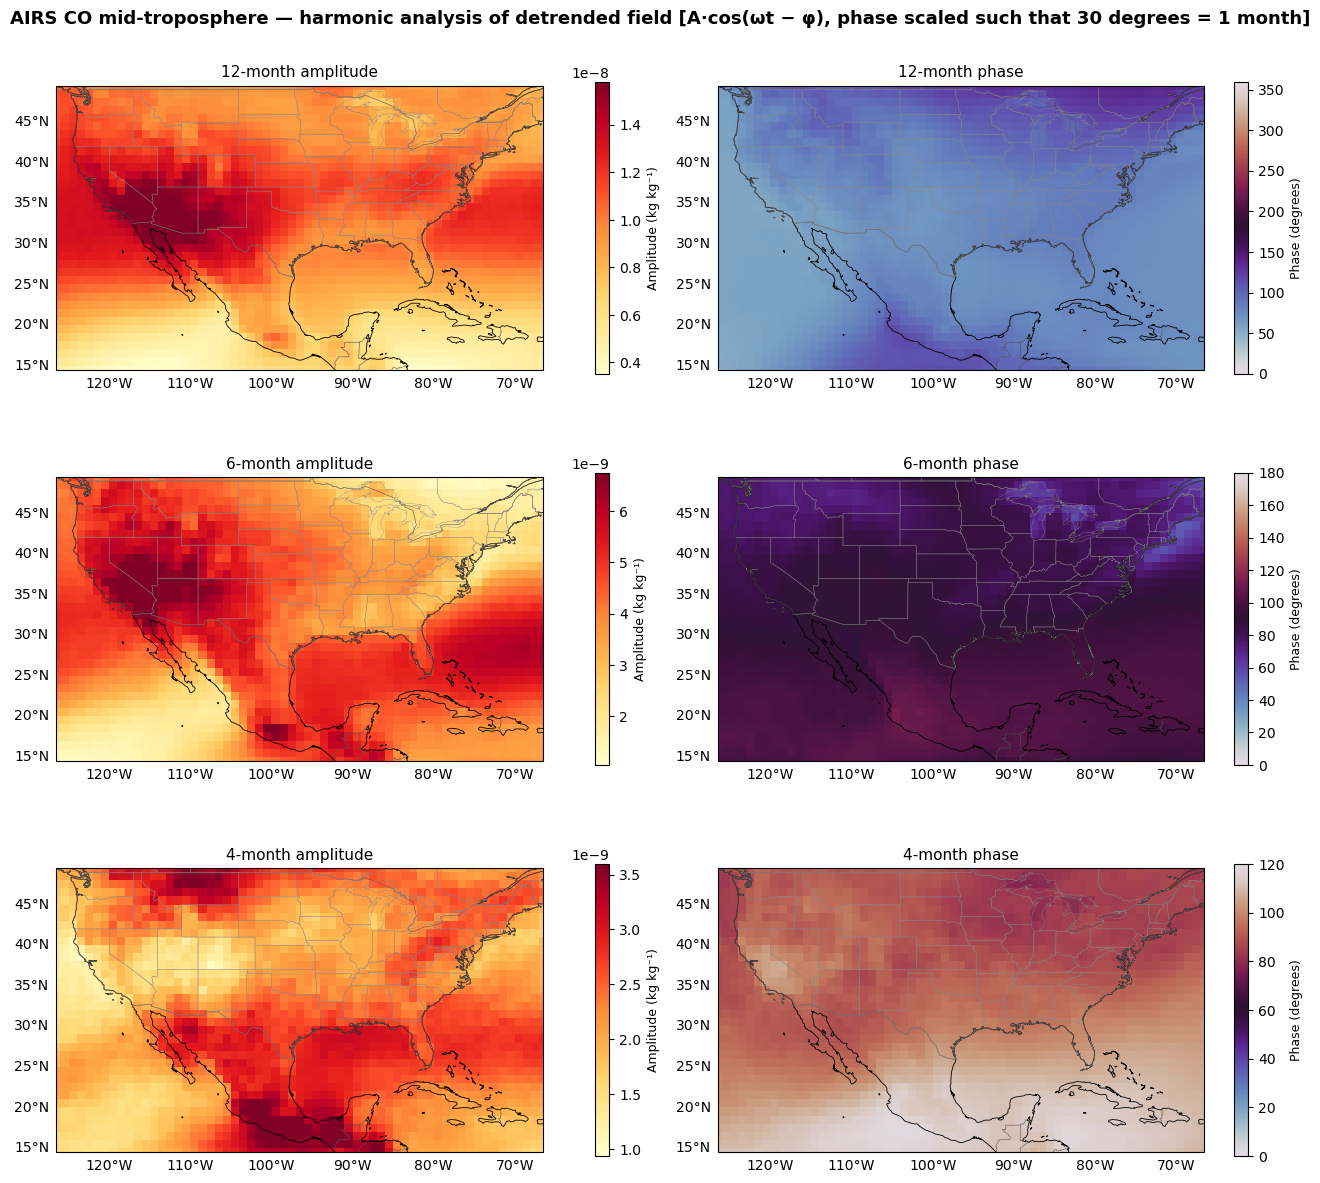

Saved -> ../Figures\harmonics_amp_phase_cos_scaled_2003_2025.png


In [10]:
fig_h2, axes_h2 = plt.subplots(
    len(periods), 2, figsize=(13, 4 * len(periods)),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True,
)

def harm_map2(ax, data, cmap, label, title, vmin=None, vmax=None):
    ax.set_extent(ext, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
    ax.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")
    pcm = ax.pcolormesh(lons, lats, data, transform=ccrs.PlateCarree(),
                        cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest")
    gl = ax.gridlines(draw_labels=True, linewidth=0, color="none")
    gl.top_labels = gl.right_labels = False
    cb = fig_h2.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)
    cb.set_label(label, fontsize=9)
    ax.set_title(title, fontsize=11, pad=6)

for r, P in enumerate(periods):
    # Scale phase from degrees (0–360) to months (0–P) via factor P/12
    pha_scaled = pha[P] * (P / 12)

    harm_map2(axes_h2[r, 0], amp[P], "YlOrRd", "Amplitude (kg kg⁻¹)",
              f"{P}-month amplitude", vmax=np.nanpercentile(amp[P], 98))
    harm_map2(axes_h2[r, 1], pha_scaled, "twilight", "Phase (degrees)",
              f"{P}-month phase", vmin=0, vmax=360*(P/12))

fig_h2.suptitle(
    "AIRS CO mid-troposphere — harmonic analysis of detrended field [A·cos(ωt − φ), phase scaled such that 30 degrees = 1 month]",
    fontsize=13, fontweight="bold")
out_h2 = os.path.join(OUT_DIR, "harmonics_amp_phase_cos_scaled_2003_2025.png")
fig_h2.savefig(out_h2, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_h2)

## Harmonic reconstruction & variance explained

In [18]:
# Reconstruct each harmonic separately and combined
recon = {}
for k, P in enumerate(periods):
    fitted = (M[:, 2*k:2*k+2] @ coef[2*k:2*k+2]).reshape(len(months), n_lat, n_lon)
    recon[P] = xr.DataArray(fitted, dims=("time","lat","lon"), coords=detr_field.coords)

recon_total = xr.DataArray(
    (M @ coef).reshape(len(months), n_lat, n_lon),
    dims=("time","lat","lon"), coords=detr_field.coords,
)

# Variance explained
var_data = float(detr_field.var("time").sum())
print(f"Total variance in detr_field : {var_data:.4e} (kg/kg)²·pixels\n")
cum = 0.0
for P in periods:
    frac = 100 * float(recon[P].var("time").sum()) / var_data
    cum += frac
    print(f"  {P:2d}-month harmonic : {frac:5.1f}%")
print(f"  Combined (all 3) : {cum:5.1f}%")
print(f"  Residual         : {100-cum:5.1f}%")

Total variance in detr_field : 1.9799e-13 (kg/kg)²·pixels

  12-month harmonic :  57.5%
   6-month harmonic :  10.6%
   4-month harmonic :   3.1%
  Combined (all 3) :  71.3%
  Residual         :  28.7%


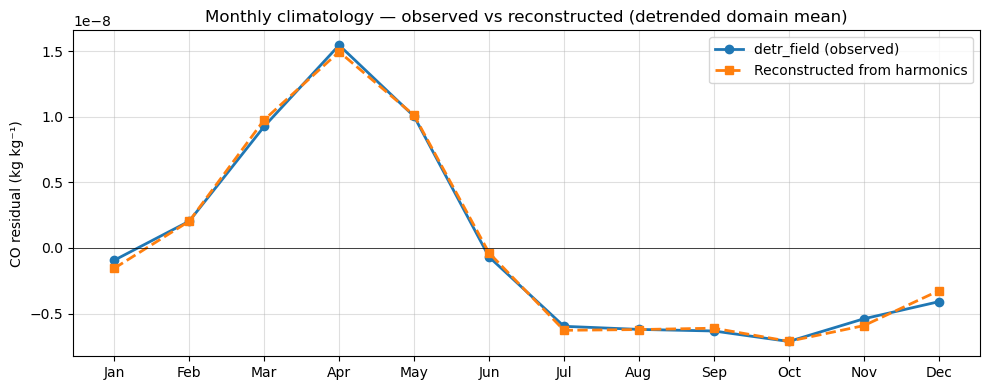

In [21]:
# Monthly climatology: domain-mean of detr_field vs harmonic reconstruction
import pandas as pd

obs_ts   = detr_field.mean(("lat","lon")).values
recon_ts = recon_total.mean(("lat","lon")).values

month_num   = pd.DatetimeIndex(months).month
obs_clim    = pd.Series(obs_ts,   index=month_num).groupby(level=0).mean()
recon_clim  = pd.Series(recon_ts, index=month_num).groupby(level=0).mean()
mnames = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mnames, obs_clim.values,   "o-", lw=2, label="detr_field (observed)")
ax.plot(mnames, recon_clim.values, "s--", lw=2, label="Reconstructed from harmonics")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("CO residual (kg kg⁻¹)")
ax.set_title("Monthly climatology — observed vs reconstructed (detrended domain mean)")
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

In [20]:
# Comparison metrics on the full time series (all pixels flattened)
from scipy.stats import pearsonr

y     = detr_field.values.ravel()
y_hat = recon_total.values.ravel()
resid = y - y_hat

ss_res = np.sum(resid**2)
ss_tot = np.sum((y - y.mean())**2)
r2     = 1 - ss_res / ss_tot
rmse   = np.sqrt(np.mean(resid**2))
mae    = np.mean(np.abs(resid))
bias   = np.mean(resid)
r, _   = pearsonr(y, y_hat)

print("Comparison metrics (full field, all pixels & times)")
print(f"  R²          : {r2:.4f}")
print(f"  Pearson r   : {r:.4f}")
print(f"  RMSE        : {rmse:.4e}  kg/kg")
print(f"  MAE         : {mae:.4e}  kg/kg")
print(f"  Bias (mean) : {bias:.4e}  kg/kg")

Comparison metrics (full field, all pixels & times)
  R²          : 0.7125
  Pearson r   : 0.8441
  RMSE        : 5.0908e-09  kg/kg
  MAE         : 3.7877e-09  kg/kg
  Bias (mean) : -1.3640e-24  kg/kg
